<a href="https://colab.research.google.com/github/ChiaraTagiullo/olympic-power-structure/blob/main/GDP_and_Olympic_Success.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Olympic Power Structure — GDP and Olympic Success

## Goal

This notebook explores whether Olympic success is related to economic power.

Main question:
Do richer countries tend to win more Olympic medals?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import os

pd.set_option("display.max_columns", None)

## 1. Upload the cleaned Olympic dataset

This notebook starts from the country-year dataset produced in the data preparation step.

In [2]:
uploaded = files.upload()

Saving olympics_country_year.csv to olympics_country_year.csv


In [3]:
print(os.listdir())

['.config', 'olympics_country_year.csv', 'sample_data']


In [4]:
olympics = pd.read_csv("olympics_country_year.csv", sep=";")
display(olympics.head())
print(olympics.columns.tolist())

,NOC,Year,Gold,Silver,Bronze,Total_Medals,Rank,Year_Total_Medals,Medal_Share,Top10_Flag
0,GRE,1896,10,17,17,44,1,120,"3,66667E+16",VERO
1,USA,1896,11,6,2,19,2,120,"1,58333E+16",VERO
2,GER,1896,7,5,2,14,3,120,"1,16667E+16",VERO
3,FRA,1896,5,4,2,11,4,120,"9,16667E+15",VERO
4,GBR,1896,3,3,3,9,5,120,75,VERO


['NOC', 'Year', 'Gold', 'Silver', 'Bronze', 'Total_Medals', 'Rank', 'Year_Total_Medals', 'Medal_Share', 'Top10_Flag']


In [5]:
if "Top10_Flag" in olympics.columns:
    olympics["Top10_Flag"] = olympics["Top10_Flag"].astype(str).str.upper() == "VERO"

olympics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1442 entries, 0 to 1441
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   NOC                1442 non-null   object
 1   Year               1442 non-null   int64 
 2   Gold               1442 non-null   int64 
 3   Silver             1442 non-null   int64 
 4   Bronze             1442 non-null   int64 
 5   Total_Medals       1442 non-null   int64 
 6   Rank               1442 non-null   int64 
 7   Year_Total_Medals  1442 non-null   int64 
 8   Medal_Share        1442 non-null   object
 9   Top10_Flag         1442 non-null   bool  
dtypes: bool(1), int64(7), object(2)
memory usage: 102.9+ KB


## 2. Load GDP data

I use a country-year GDP dataset to compare national economic power with Olympic performance.

In [6]:
gdp = pd.read_csv("https://raw.githubusercontent.com/datasets/gdp/master/data/gdp.csv")
display(gdp.head())
print(gdp.columns.tolist())

,Country Name,Country Code,Year,Value
0,Afghanistan,AFG,2000,3.521418e+09
1,Afghanistan,AFG,2001,2.813572e+09
2,Afghanistan,AFG,2002,3.825701e+09
3,Afghanistan,AFG,2003,4.520947e+09
4,Afghanistan,AFG,2004,5.224897e+09


['Country Name', 'Country Code', 'Year', 'Value']


## 3. Keep only the variables needed for the analysis

To merge GDP data with Olympic data, I keep:
- country code
- year
- GDP value

In [7]:
gdp = gdp[["Country Name", "Country Code", "Year", "Value"]].copy()
gdp = gdp.rename(columns={
    "Country Name": "Country",
    "Country Code": "NOC",
    "Value": "GDP"
})

display(gdp.head())
gdp.info()

,Country,NOC,Year,GDP
0,Afghanistan,AFG,2000,3.521418e+09
1,Afghanistan,AFG,2001,2.813572e+09
2,Afghanistan,AFG,2002,3.825701e+09
3,Afghanistan,AFG,2003,4.520947e+09
4,Afghanistan,AFG,2004,5.224897e+09


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13979 entries, 0 to 13978
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  13979 non-null  object 
 1   NOC      13979 non-null  object 
 2   Year     13979 non-null  int64  
 3   GDP      13979 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 437.0+ KB


In [8]:
print("GDP year range:", gdp["Year"].min(), "-", gdp["Year"].max())

GDP year range: 1960 - 2023


In [9]:
print("Olympics year range:", olympics["Year"].min(), "-", olympics["Year"].max())

Olympics year range: 1896 - 2016


## 4. Merge Olympic performance with GDP data

I merge the two datasets by:
- country code (`NOC`)
- year

In [10]:
merged = olympics.merge(gdp, on=["NOC", "Year"], how="left")
display(merged.head())
print(merged.shape)

,NOC,Year,Gold,Silver,Bronze,Total_Medals,Rank,Year_Total_Medals,Medal_Share,Top10_Flag,Country,GDP
0,GRE,1896,10,17,17,44,1,120,"3,66667E+16",True,NaN,NaN
1,USA,1896,11,6,2,19,2,120,"1,58333E+16",True,NaN,NaN
2,GER,1896,7,5,2,14,3,120,"1,16667E+16",True,NaN,NaN
3,FRA,1896,5,4,2,11,4,120,"9,16667E+15",True,NaN,NaN
4,GBR,1896,3,3,3,9,5,120,75,True,NaN,NaN


(1442, 12)


## 5. Check GDP coverage after the merge

In [11]:
missing_gdp_share = merged["GDP"].isna().mean()
missing_gdp_share

np.float64(0.5104022191400832)

In [12]:
merged["GDP"].isna().sum()

np.int64(736)

In [13]:
missing_gdp_countries = merged.loc[merged["GDP"].isna(), "NOC"].drop_duplicates().tolist()
missing_gdp_countries[:50]

['GRE',
 'USA',
 'GER',
 'FRA',
 'GBR',
 'HUN',
 'DEN',
 'AUT',
 'AUS',
 'SUI',
 'BEL',
 'NED',
 'ITA',
 'NOR',
 'BOH',
 'CUB',
 'CAN',
 'SWE',
 'IND',
 'ESP',
 'HAI',
 'LUX',
 'NZL',
 'COL',
 'MEX',
 'FIN',
 'ANZ',
 'RUS',
 'RSA',
 'EST',
 'BRA',
 'JPN',
 'TCH',
 'ARG',
 'YUG',
 'IRL',
 'POL',
 'NEP',
 'URU',
 'MON',
 'POR',
 'ROU',
 'EGY',
 'CHI',
 'PHI',
 'LAT',
 'TUR',
 'JAM',
 'KOR',
 'PAN']

## 6. Filter reliable observations

A large share of observations does not have matching GDP data.

This is due to:
- historical country codes (e.g. Yugoslavia, Bohemia)
- mismatches between Olympic NOC codes and ISO country codes

To ensure a reliable analysis, I keep only observations with available GDP data.

In [14]:
analysis_df = merged.dropna(subset=["GDP"]).copy()

print("Remaining observations:", analysis_df.shape[0])
print("Remaining share:", analysis_df.shape[0] / merged.shape[0])

analysis_df.head()

Remaining observations: 706
Remaining share: 0.4895977808599168


,NOC,Year,Gold,Silver,Bronze,Total_Medals,Rank,Year_Total_Medals,Medal_Share,Top10_Flag,Country,GDP
372,USA,1960,37,25,19,81,2,542,"1,49446E+16",True,United States,5.419886e+11
374,ITA,1960,13,10,14,37,4,542,"6,82657E+15",True,Italy,4.191581e+10
376,AUS,1960,8,8,6,22,6,542,"4,05904E+15",True,Australia,1.860656e+10
378,GBR,1960,2,6,12,20,8,542,"3,69004E+15",True,United Kingdom,7.323397e+10
379,JPN,1960,4,7,7,18,9,542,"3,32103E+16",True,Japan,4.741924e+10


This filtering step reduces the dataset significantly, but ensures that the analysis is based on consistent and comparable country-year observations.

## 7. Inspect GDP distribution

Before plotting, I inspect the scale of GDP values.

In [15]:
analysis_df["GDP"].describe()

,GDP
count,7.060000e+02
mean,7.306233e+11
std,2.013936e+12
min,2.724893e+08
25%,2.008666e+10
50%,1.091302e+11
75%,4.675260e+11
max,1.880491e+13


## 8. Log-transform GDP

GDP values span several orders of magnitude, so I use a logarithmic scale to make comparisons more interpretable.

In [16]:
analysis_df["log_GDP"] = np.log10(analysis_df["GDP"])
analysis_df[["NOC", "Year", "GDP", "log_GDP"]].head()

,NOC,Year,GDP,log_GDP
372,USA,1960,5.419886e+11,11.733990
374,ITA,1960,4.191581e+10,10.622378
376,AUS,1960,1.860656e+10,10.269666
378,GBR,1960,7.323397e+10,10.864713
379,JPN,1960,4.741924e+10,10.675955


## 9. GDP and Olympic medals

I now visualize the relationship between economic power and Olympic success.

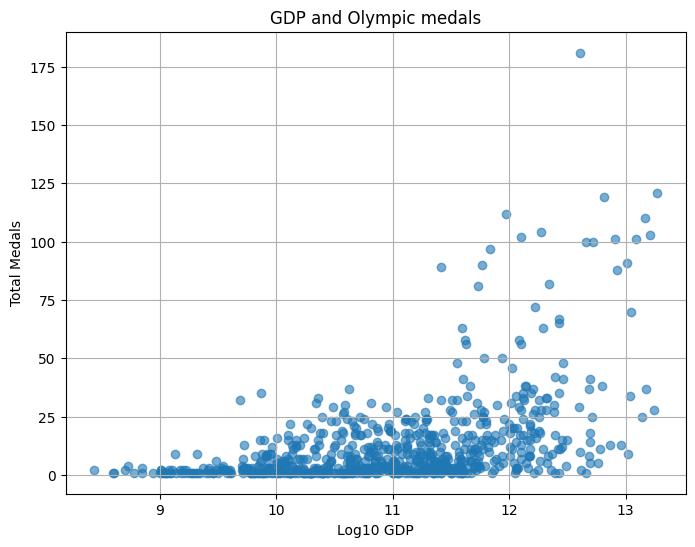

In [17]:
plt.figure(figsize=(8,6))
plt.scatter(
    analysis_df["log_GDP"],
    analysis_df["Total_Medals"],
    alpha=0.6
)

plt.xlabel("Log10 GDP")
plt.ylabel("Total Medals")
plt.title("GDP and Olympic medals")
plt.grid()
plt.show()

## Interpretation

The scatter plot shows a clear positive relationship between GDP and Olympic performance.

Countries with higher GDP tend to win more medals, suggesting that economic resources play an important role in Olympic success.

However, the relationship is not perfect.  
There is substantial variation among countries with similar GDP levels, especially among wealthier nations.

This indicates that while economic power is a key factor, it does not fully determine Olympic outcomes.

Some countries achieve significantly better results than others with comparable economic resources.

## 10. Correlation between GDP and medals

In [18]:
correlation = analysis_df[["log_GDP", "Total_Medals"]].corr().iloc[0, 1]
correlation

np.float64(0.4741084273320404)

The correlation between GDP and Olympic medals is approximately 0.47.

This indicates a moderate positive relationship:
countries with higher GDP tend to win more medals, but the relationship is far from perfect.

This suggests that economic power plays an important role in Olympic success, but does not fully explain it.

## Interpretation

The analysis shows that GDP is positively associated with Olympic performance.

Richer countries generally achieve better results, confirming that economic resources contribute to success in international sports.

However, the relationship is not deterministic.  
There is significant variation among countries with similar GDP levels.

This means that while wealth provides an advantage, it does not guarantee Olympic success.

Other factors, such as sports policies, talent development, and specialization strategies, also play a crucial role.

## 11. Trend line

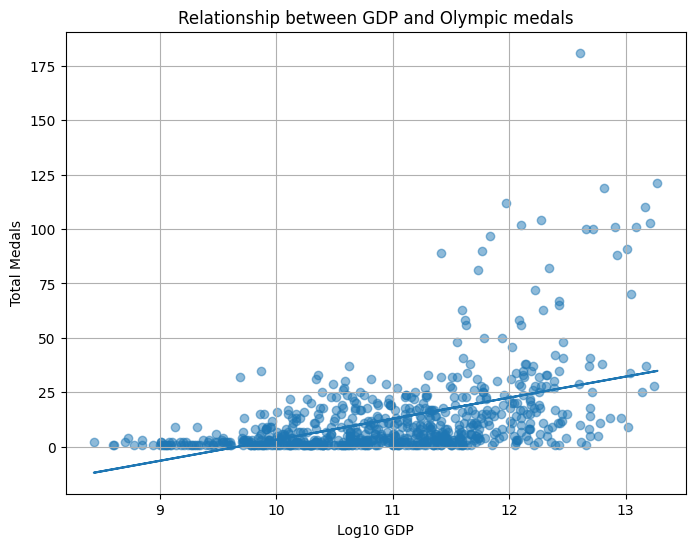

In [19]:
x = analysis_df["log_GDP"]
y = analysis_df["Total_Medals"]

coef = np.polyfit(x, y, 1)
poly1d_fn = np.poly1d(coef)

plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.5)
plt.plot(x, poly1d_fn(x))

plt.xlabel("Log10 GDP")
plt.ylabel("Total Medals")
plt.title("Relationship between GDP and Olympic medals")
plt.grid()
plt.show()

## 12. Predicted medals and residuals

To identify overperforming and underperforming countries, I compare actual medals with medals predicted by GDP.

In [20]:
analysis_df["Predicted_Medals"] = poly1d_fn(analysis_df["log_GDP"])
analysis_df["Residual"] = analysis_df["Total_Medals"] - analysis_df["Predicted_Medals"]

analysis_df[["NOC", "Year", "Total_Medals", "Predicted_Medals", "Residual"]].head()

,NOC,Year,Total_Medals,Predicted_Medals,Residual
372,USA,1960,81,19.977005,61.022995
374,ITA,1960,37,9.226406,27.773594
376,AUS,1960,22,5.815268,16.184732
378,GBR,1960,20,11.570068,8.429932
379,JPN,1960,18,9.744556,8.255444


## 13. Countries performing above GDP expectations

In [21]:
overperformers = analysis_df.sort_values("Residual", ascending=False)

overperformers[["NOC", "Year", "Total_Medals", "GDP", "Residual"]].head(10)

,NOC,Year,Total_Medals,GDP,Residual
635,USA,1984,181,4.037613e+12,152.588427
459,USA,1968,112,9.402250e+11,89.709246
740,USA,1992,119,6.520327e+12,88.575423
1356,USA,2016,121,1.880491e+13,86.126663
553,USA,1976,104,1.873412e+12,78.813681
504,USA,1972,102,1.279110e+12,78.416441
1133,USA,2008,110,1.476986e+13,76.141120
416,USA,1964,97,6.841446e+11,76.044680
930,RUS,2000,89,2.597101e+11,72.112948
1134,CHN,2008,100,4.594337e+12,71.045892


Some countries consistently perform above what their GDP would predict.

For example:
- the United States shows very large positive residuals across multiple years
- countries such as Russia and China also exceed expectations

These countries convert their economic resources into Olympic success very efficiently.

This suggests the presence of strong sports systems, investment strategies, and institutional support.

## 14. Countries performing below GDP expectations

In [22]:
underperformers = analysis_df.sort_values("Residual", ascending=True)

underperformers[["NOC", "Year", "Total_Medals", "GDP", "Residual"]].head(10)

,NOC,Year,Total_Medals,GDP,Residual
1127,JPN,2006,1,4.601663e+12,-27.960800
1029,JPN,2002,2,4.182846e+12,-26.559998
1130,GBR,2006,1,2.708442e+12,-25.734540
1242,GBR,2010,1,2.485483e+12,-25.373721
1234,JPN,2010,5,5.759072e+12,-24.903137
814,JPN,1994,5,4.998798e+12,-24.308486
1419,IND,2016,2,2.294797e+12,-24.038455
928,GBR,1998,1,1.653695e+12,-23.662354
1340,CHN,2014,9,1.047562e+13,-23.415975
1349,GBR,2014,4,3.064708e+12,-23.253589


Other countries perform below what their GDP would suggest.

For example:
- Japan and the United Kingdom show several years with low medal counts relative to their economic size
- India also appears as an underperformer despite its growing GDP

This indicates that having economic resources is not sufficient:  
countries must also effectively translate those resources into athletic performance.

## Conclusion

The results show that Olympic success is partially explained by economic power.

GDP provides a strong structural advantage, but it does not fully determine outcomes.

Some countries consistently outperform expectations, while others underperform.

This suggests that Olympic success depends not only on wealth,  
but also on how countries invest in sports systems, training, and specialization.

Therefore, Olympic performance reflects a combination of economic capacity and strategic choices.

If economic power alone does not fully explain Olympic success,  
what other mechanisms are at play?

One possible explanation is specialization:
countries may focus their efforts on specific sports where they have a competitive advantage.

In the next section, I explore how countries specialize across different Olympic disciplines.